HW 3: Natural Language Processing

Name: Lucas Huynh

AndrewID: lqh

Date: February 19, 2026

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
import nltk

### Step 1: Exploratory Data Analysis & Data Preparation

Begin by conducting a structured exploratory analysis of the Twitter US Airline Sentiment dataset to understand 
how passengers use social media to express their experiences.

Examine data completeness, missing values, 
duplicates,  and  the  distribution  of  sentiment  labels  and  airlines.  As  part  of  your  EDA,  you  should  visualize 
sentiment distributions across airlines and comment on any imbalances or behavioral patterns that emerge. Your 
reflections in this section should explain what these early patterns imply about customer feedback behavior and 
why social media data tends to skew negative. 


Clean the tweet text to prepare it for downstream analysis. This includes removing URLs, mentions, hashtags 
(while  retaining  the  actual  words),  excessive  punctuation,  and  normalizing  whitespace,  while  preserving 
emotionally meaningful text such as negations and intensifiers. At the end of this section, you should provide a 
brief  summary  in  your  report  highlighting  the  most  important  patterns  you  observe,  why  they  matter  for 
understanding airline customer experience, and any data quality issues you need to address.

#### 1.1. Data Overview

In [9]:
# read in the tweets
df = pd.read_csv("Tweets.csv")

In [15]:
print("DATASET OVERVIEW")

print(f"\nTotal records: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

print("\nData Types")
print(df.dtypes)

print("\nSample Records")
# focus on key columns for text analysis
display(df[['airline', 'airline_sentiment', 'negativereason', 'text']].head(5))

DATASET OVERVIEW

Total records: 14,640
Number of columns: 15

Data Types
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Sample Records


,airline,airline_sentiment,negativereason,text
0,Virgin America,neutral,NaN,@VirginAmerica What @dhepburn said.
1,Virgin America,positive,NaN,@VirginAmerica plus you've added commercials t...
2,Virgin America,neutral,NaN,@VirginAmerica I didn't today... Must mean I n...
3,Virgin America,negative,Bad Flight,@VirginAmerica it's really aggressive to blast...
4,Virgin America,negative,Can't Tell,@VirginAmerica and it's a really big bad thing...


#### 1.2. Missing Values Analysis

In [10]:
print("MISSING VALUES ANALYSIS")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("\nColumns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])

MISSING VALUES ANALYSIS

Columns with missing values:
                           Missing Count  Missing %
negativereason_gold                14608      99.78
airline_sentiment_gold             14600      99.73
tweet_coord                        13621      93.04
negativereason                      5462      37.31
user_timezone                       4820      32.92
tweet_location                      4733      32.33
negativereason_confidence           4118      28.13


In [14]:
# insight for text analysis
text_missing = df['text'].isnull().sum()

print(f"\nText column missing: {text_missing} ({text_missing/len(df)*100:.1f}%)")
print(f"Records available for text analysis: {len(df) - text_missing:,}")


Text column missing: 0 (0.0%)
Records available for text analysis: 14,640


#### 1.3. Duplicate Detection

In [ ]:
print("DUPLICATE ANALYSIS")

# check for duplicate tweet IDs and text entries
duplicate_ids = df['tweet_id'].duplicated().sum()
duplicate_text = df['text'].duplicated().sum()

print(f"\nDuplicate tweet IDs: {duplicate_ids}")
print(f"Duplicate tweet text entries: {duplicate_text}")

DUPLICATE ANALYSIS

Duplicate tweet IDs: 155
Duplicate tweet text entries: 213


In [13]:
# inspect duplicate text entries
df[df['text'].duplicated(keep=False)][['tweet_id', 'text']].sort_values('text').head(10)

,tweet_id,text
12067,570301488192458752,.@AmericanAir can you connect me to a person w...
11906,570301488192458752,.@AmericanAir can you connect me to a person w...
11902,570303383782989824,.@AmericanAir just disappointed with the Fligh...
12063,570303383782989824,.@AmericanAir just disappointed with the Fligh...
11946,570288282413633536,@AmericanAir\n Your response could have made a...
12107,570288282413633536,@AmericanAir\n Your response could have made a...
12128,570281010606120960,@AmericanAir \nIt's not what happens to us tha...
11967,570281010606120960,@AmericanAir \nIt's not what happens to us tha...
13995,569680231012773888,@AmericanAir 800 number will not even let you...
12029,569680231012773888,@AmericanAir 800 number will not even let you...


In [16]:
# remove duplicates if present
if duplicate_text > 0:
    print(f"\nRecommendation: Remove {duplicate_text} duplicate text entries")
    df_clean = df.drop_duplicates(subset='text', keep='first')
    print(f"Dataset size after deduplication: {len(df_clean):,}")
else:
    df_clean = df.copy()


Recommendation: Remove 213 duplicate text entries
Dataset size after deduplication: 14,427


#### 1.4. Sentiment Distribution

In [17]:
print("SENTIMENT DISTRIBUTION")

# airline sentiment distribution
sentiment_counts = df_clean['airline_sentiment'].value_counts()

print("\nOverall Sentiment Breakdown")
for sentiment in sentiment_counts.index:
    count = sentiment_counts[sentiment]
    pct = count / len(df_clean) * 100
    print(f"  {sentiment}: {count:,} ({pct:.1f}%)")

SENTIMENT DISTRIBUTION

Overall Sentiment Breakdown
  negative: 9,080 (62.9%)
  neutral: 3,057 (21.2%)
  positive: 2,290 (15.9%)


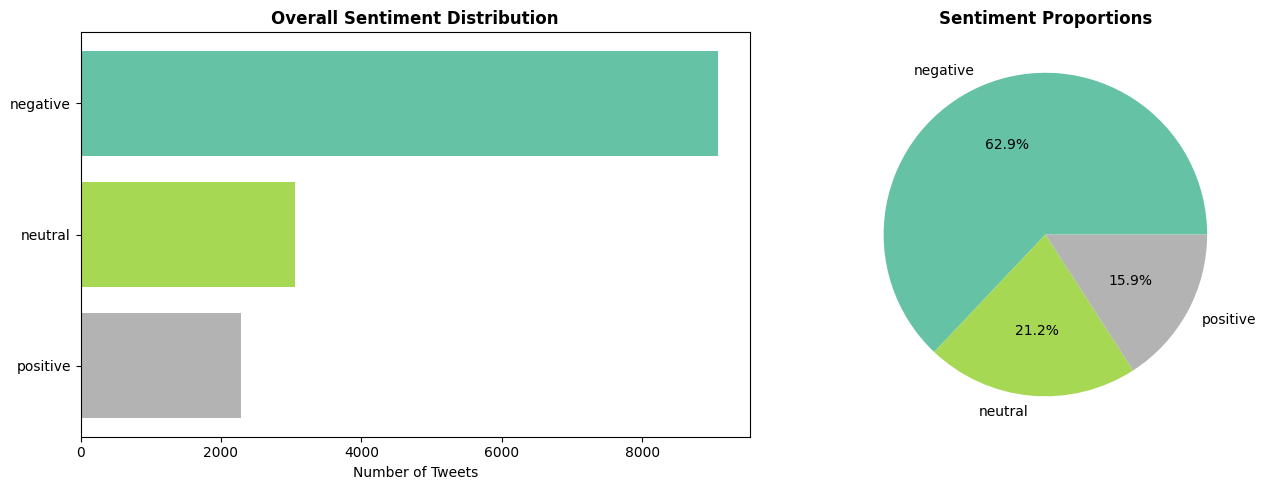

In [19]:
# visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(sentiment_counts)))

# bar chart
axes[0].barh(sentiment_counts.index[::-1],
             sentiment_counts.values[::-1],
             color=colors[::-1])
axes[0].set_xlabel('Number of Tweets')
axes[0].set_title('Overall Sentiment Distribution', fontweight='bold')

# pie chart
axes[1].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=colors)
axes[1].set_title('Sentiment Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.5. Sentiment Distribution by Airline

In [20]:
print("SENTIMENT BY AIRLINE")

airlines = df_clean['airline'].unique()

for airline in airlines:
    subset = df_clean[df_clean['airline'] == airline]
    counts = subset['airline_sentiment'].value_counts()
    
    print(f"\n{airline}")
    for sentiment in counts.index:
        count = counts[sentiment]
        pct = count / len(subset) * 100
        print(f"  {sentiment}: {count:,} ({pct:.1f}%)")

SENTIMENT BY AIRLINE

Virgin America
  negative: 181 (36.0%)
  neutral: 171 (34.0%)
  positive: 151 (30.0%)

United
  negative: 2,633 (69.2%)
  neutral: 694 (18.2%)
  positive: 478 (12.6%)

Southwest
  negative: 1,185 (49.2%)
  neutral: 658 (27.3%)
  positive: 565 (23.5%)

Delta
  negative: 955 (43.2%)
  neutral: 723 (32.7%)
  positive: 533 (24.1%)

US Airways
  negative: 2,262 (77.8%)
  neutral: 380 (13.1%)
  positive: 264 (9.1%)

American
  negative: 1,864 (71.9%)
  neutral: 431 (16.6%)
  positive: 299 (11.5%)


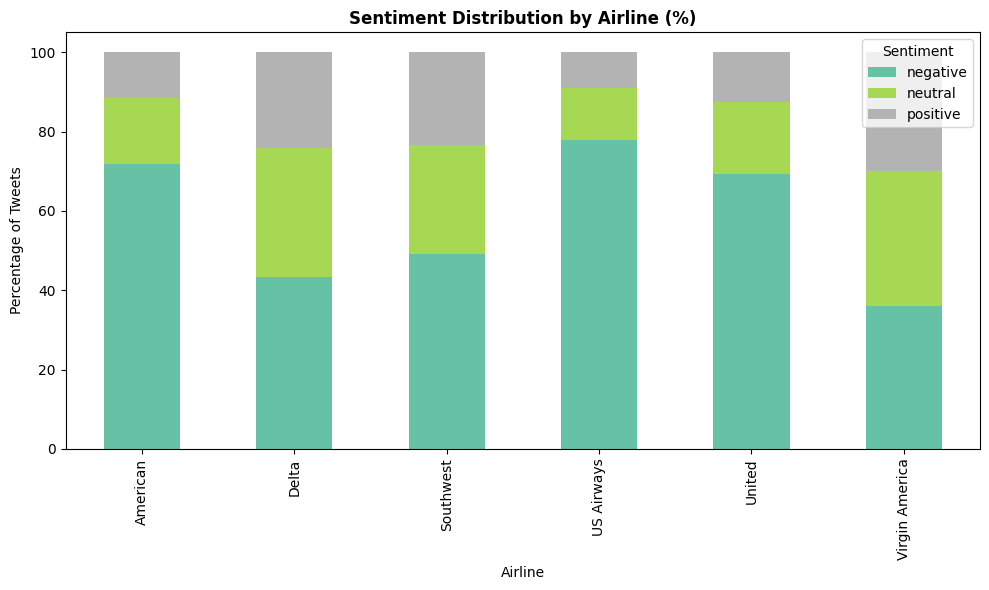

In [21]:
sentiment_by_airline = pd.crosstab(
    df_clean['airline'],
    df_clean['airline_sentiment'],
    normalize='index'
) * 100

sentiment_by_airline = sentiment_by_airline.round(1)

sentiment_by_airline.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)

plt.title("Sentiment Distribution by Airline (%)", fontweight='bold')
plt.ylabel("Percentage of Tweets")
plt.xlabel("Airline")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

#### 1.6. Text Pre-Processing and Cleaning

In [ ]:
print("TEXT CLEANING")

def clean_text(text):
    """
    Cleans the input text by removing URLs, @mentions, special characters (except emotionally relevant punctuation), 
    and normalizing whitespace. It also converts text to lowercase for uniformity.

    Args:
        text (str): The raw text to be cleaned.

    Returns:
        str: The cleaned text.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # remove @mentions
    text = re.sub(r'@\w+', '', text)

    # keep hashtag words, remove #
    text = re.sub(r'#(\w+)', r'\1', text)

    # remove special characters but keep emotionally relevant punctuation
    text = re.sub(r'[^a-zA-Z0-9\s!?\'\-]', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # lowercase
    text = text.lower()

    return text

TEXT CLEANING


In [24]:
# apply the cleaning
df_clean['text_clean'] = df_clean['text'].apply(clean_text)

/var/folders/hj/_jmscth928bcdm9fr013zqzr0000gn/T/ipykernel_61627/837489750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_clean'] = df_clean['text'].apply(clean_text)


In [25]:
print("TEXT CLEANING EXAMPLES")

for i in range(3):
    print(f"\nExample {i+1}")
    print(f"BEFORE: {df_clean.iloc[i]['text'][:200]}")
    print(f"AFTER:  {df_clean.iloc[i]['text_clean'][:200]}")

TEXT CLEANING EXAMPLES

Example 1
BEFORE: @VirginAmerica What @dhepburn said.
AFTER:  what said

Example 2
BEFORE: @VirginAmerica plus you've added commercials to the experience... tacky.
AFTER:  plus you've added commercials to the experience tacky

Example 3
BEFORE: @VirginAmerica I didn't today... Must mean I need to take another trip!
AFTER:  i didn't today must mean i need to take another trip!


In [26]:
# key text statistics
print("TEXT STATISTICS")

df_text = df_clean[df_clean['text_clean'].str.len() > 0].copy()

df_text['text_length'] = df_text['text_clean'].apply(len)
df_text['word_count'] = df_text['text_clean'].apply(lambda x: len(x.split()))

print(f"\nRecords with text: {len(df_text):,}")

print(f"\nText Length (characters):")
print(f"  Mean: {df_text['text_length'].mean():.1f}")
print(f"  Median: {df_text['text_length'].median():.1f}")
print(f"  Max: {df_text['text_length'].max():,}")

print(f"\nWord Count:")
print(f"  Mean: {df_text['word_count'].mean():.1f}")
print(f"  Median: {df_text['word_count'].median():.1f}")

TEXT STATISTICS

Records with text: 14,427

Text Length (characters):
  Mean: 87.4
  Median: 96.0
  Max: 167

Word Count:
  Mean: 16.6
  Median: 18.0


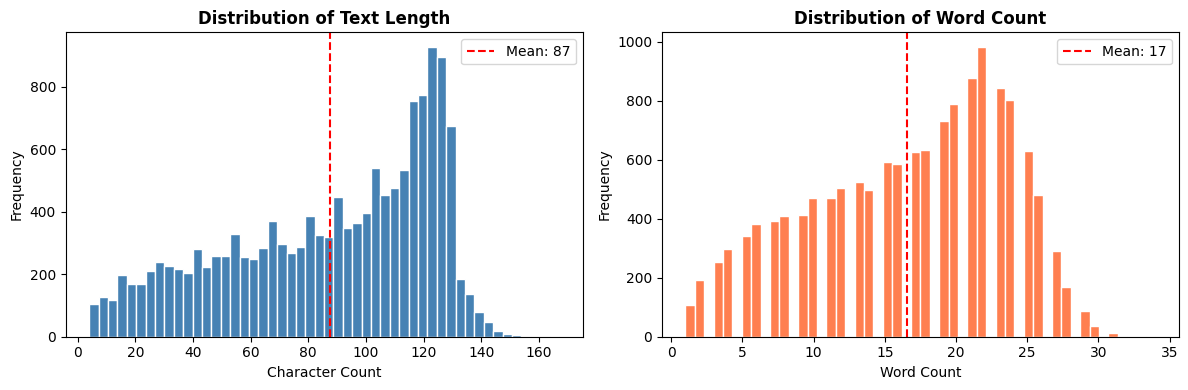

In [27]:
# visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_text['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length', fontweight='bold')
axes[0].axvline(df_text['text_length'].mean(),
                color='red',
                linestyle='--',
                label=f"Mean: {df_text['text_length'].mean():.0f}")
axes[0].legend()

axes[1].hist(df_text['word_count'], bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count', fontweight='bold')
axes[1].axvline(df_text['word_count'].mean(),
                color='red',
                linestyle='--',
                label=f"Mean: {df_text['word_count'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 2: Reason & Theme Analysis

In this section, you should analyze why customers express dissatisfaction by studying the negativereason field. 
The dataset includes a mixture of human-annotated reasons and missing values. You should use this existing 
data as a starting point, then fill in missing or ambiguous entries using an LLM. You can provide the entire dataset 
to  an  LLM  of  your  choice  and  ask  it  to  give  you  the  negative  reasons  for  all  negative  tweets.    This  creates  a 
cleaner, more consistent view of complaint drivers.

Once you have this enriched reason field, you should analyze how different types of issues are distributed across 
airlines and throughout the day. You should visualize these patterns as you see fit. You should then reflect in 
your  report  on  your  experience  using  the  LLM  to  infer  categories:  whether  the  generated  reasons  appeared 
reasonable  upon  inspection,  how  consistent  the  model  was,  and  any  cases  where  the  model  struggled.  Your 
analysis should connect these themes to real operational and service breakdowns in the airline industry. 

In [28]:
# grab cleaned data from step 1
df_clean = df.copy()

#### 2.1. Negative Tweets and Human Reason Missingness

In [ ]:
print("NEGATIVE REASON ANALYSIS - SETUP")

# check for missing reasons
df_neg = df_clean[df_clean['airline_sentiment'] == 'negative'].copy()

print(f"\nTotal tweets: {len(df_clean):,}")
print(f"Negative tweets: {len(df_neg):,} ({len(df_neg)/len(df_clean)*100:.1f}%)")

reason_col = 'negativereason'
reason_missing = df_neg[reason_col].isnull().sum()

print(f"\nMissing negativereason: {reason_missing:,} ({reason_missing/len(df_neg)*100:.1f}%)")
print(f"With human negativereason: {len(df_neg) - reason_missing:,}")

NEGATIVE REASON ANALYSIS - SETUP

Total tweets: 14,640
Negative tweets: 9,178 (62.7%)

Missing negativereason: 0 (0.0%)
With human negativereason: 9,178


#### 2.2. Human-labeled Reason Distribution

In [30]:
print("HUMAN-LABELED NEGATIVE REASONS")

reason_counts = df_neg['negativereason'].value_counts(dropna=False)

print("\n--- Top 12 reasons (including NaN) ---")
for reason in reason_counts.index[:12]:
    count = reason_counts[reason]
    pct = count / len(df_neg) * 100
    print(f"  {reason}: {count:,} ({pct:.1f}%)")

HUMAN-LABELED NEGATIVE REASONS

--- Top 12 reasons (including NaN) ---
  Customer Service Issue: 2,910 (31.7%)
  Late Flight: 1,665 (18.1%)
  Can't Tell: 1,190 (13.0%)
  Cancelled Flight: 847 (9.2%)
  Lost Luggage: 724 (7.9%)
  Bad Flight: 580 (6.3%)
  Flight Booking Problems: 529 (5.8%)
  Flight Attendant Complaints: 481 (5.2%)
  longlines: 178 (1.9%)
  Damaged Luggage: 74 (0.8%)


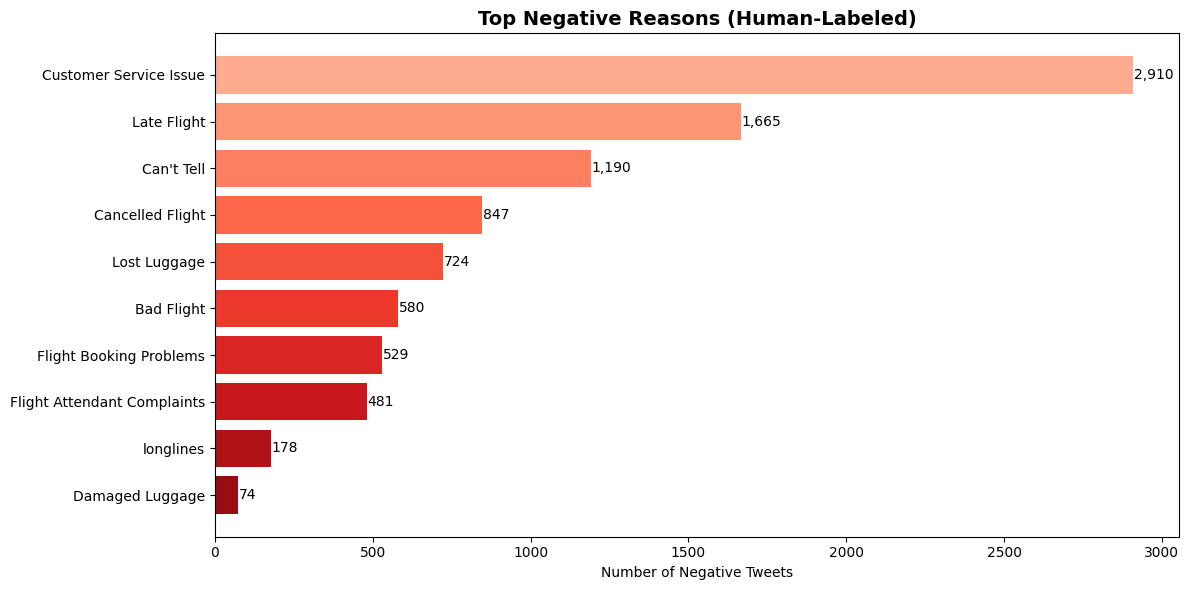

In [31]:
# visualization
top_k = 10
top_reasons = df_neg['negativereason'].value_counts().head(top_k)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_reasons)))[::-1]
bars = ax.barh(top_reasons.index[::-1], top_reasons.values[::-1], color=colors)

ax.set_xlabel('Number of Negative Tweets')
ax.set_title('Top Negative Reasons (Human-Labeled)', fontweight='bold', fontsize=14)

for bar, val in zip(bars, top_reasons.values[::-1]):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### 2.3. AI-labeled Reason Distribution (code from here is from the AI)

In [43]:
# If you don't already have transformers installed:
# !pip install transformers torch -q

import numpy as np
import pandas as pd
from transformers import pipeline

# 1) Work on negative tweets only
df_neg = df_clean[df_clean["airline_sentiment"] == "negative"].copy()

# 2) Define which rows are "ambiguous"
LOW_CONF_THRESH = 0.60
ambiguous_mask = (
    (df_neg["negativereason"] == "Can't Tell") |
    (df_neg["negativereason_confidence"] < LOW_CONF_THRESH)
)

print("AMBIGUITY SETUP")
print(f"Negative tweets: {len(df_neg):,}")
print(f"Ambiguous tweets to relabel: {ambiguous_mask.sum():,} ({ambiguous_mask.mean()*100:.1f}%)")

# 3) Candidate labels: use existing taxonomy but EXCLUDE "Can't Tell"
candidate_labels = sorted([x for x in df_neg["negativereason"].unique().tolist() if x != "Can't Tell"])
candidate_labels.append("Other")

print("\nCandidate labels:")
for lab in candidate_labels:
    print(" -", lab)

# 4) Load zero-shot classifier
zsc = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# 5) Predict for ambiguous tweets (batching)
texts = df_neg.loc[ambiguous_mask, "text"].astype(str).tolist()

BATCH_SIZE = 32
pred_labels = []
pred_scores = []

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    out = zsc(batch, candidate_labels, multi_label=False)

    if isinstance(out, dict):
        out = [out]

    for o in out:
        pred_labels.append(o["labels"][0])
        pred_scores.append(o["scores"][0])

# 6) Store model outputs
df_neg.loc[ambiguous_mask, "llm_reason"] = pred_labels
df_neg.loc[ambiguous_mask, "llm_reason_score"] = pred_scores

# CONSERVATIVE ADJUSTMENT
MIN_MODEL_SCORE = 0.50  # Only trust model if moderately confident

low_model_conf = df_neg["llm_reason_score"].fillna(0) < MIN_MODEL_SCORE

# If model confidence is low, revert back to original human label
df_neg.loc[ambiguous_mask & low_model_conf, "llm_reason"] = df_neg.loc[
    ambiguous_mask & low_model_conf, "negativereason"
]

# 7) Create enriched reason:
# - Keep confident human labels
# - Replace ambiguous ones only if model is confident
df_neg["negativereason_enriched"] = df_neg["negativereason"]

keep_human_mask = (~ambiguous_mask) & (df_neg["negativereason"].notnull())
df_neg.loc[~keep_human_mask, "negativereason_enriched"] = df_neg.loc[
    ~keep_human_mask, "llm_reason"
]

df_neg["negativereason_enriched"] = df_neg["negativereason_enriched"].fillna("Other")

print("\nENRICHED FIELD CHECK")
print("Missing enriched:", df_neg["negativereason_enriched"].isnull().sum())
print("Unique enriched labels:", df_neg["negativereason_enriched"].nunique())

# Diagnostic: how many actually replaced?
replaced = (ambiguous_mask & ~low_model_conf).sum()
print(f"\nTweets relabeled by model (confident replacements): {replaced:,} ({replaced/len(df_neg)*100:.1f}%)")

print("\nLLM SCORE SUMMARY (ambiguous only)")
print(df_neg.loc[ambiguous_mask, "llm_reason_score"].describe())

AMBIGUITY SETUP
Negative tweets: 9,178
Ambiguous tweets to relabel: 2,602 (28.4%)

Candidate labels:
 - Bad Flight
 - Cancelled Flight
 - Customer Service Issue
 - Damaged Luggage
 - Flight Attendant Complaints
 - Flight Booking Problems
 - Late Flight
 - Lost Luggage
 - longlines
 - Other


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]


ENRICHED FIELD CHECK
Missing enriched: 0
Unique enriched labels: 11

Tweets relabeled by model (confident replacements): 461 (5.0%)

LLM SCORE SUMMARY (ambiguous only)
count    2602.000000
mean        0.370520
std         0.139247
min         0.139154
25%         0.266026
50%         0.340211
75%         0.447642
max         0.894458
Name: llm_reason_score, dtype: float64


In [44]:
# Sample a few ambiguous tweets and inspect the relabel
display(
    df_neg.loc[ambiguous_mask, ["airline", "negativereason", "negativereason_confidence", "llm_reason", "llm_reason_score", "text"]]
    .sample(12, random_state=42)
)

,airline,negativereason,negativereason_confidence,llm_reason,llm_reason_score,text
9432,US Airways,Customer Service Issue,0.3437,Customer Service Issue,0.403316,"@usairways really need help asap, so please ma..."
1138,United,Can't Tell,0.3546,Can't Tell,0.162685,"@united e-ticket # 0162389030167, refund reque..."
1347,United,longlines,0.3684,longlines,0.210653,@united please stop spending mktg $ on brandin...
12020,American,Customer Service Issue,0.3337,Late Flight,0.664238,@AmericanAir The issue is the lack of consider...
13727,American,Flight Booking Problems,0.3637,Flight Booking Problems,0.375088,@AmericanAir it was my friend. She shouldn't h...
11013,US Airways,Customer Service Issue,0.3407,Customer Service Issue,0.262861,@USAirways even when I do simple google search...
12541,American,Lost Luggage,0.3380,Lost Luggage,0.403110,"@AmericanAir checked in at Des Moines, lay ove..."
2444,United,Can't Tell,0.3469,Can't Tell,0.178872,@united is to airlines as @comcast @XFINITY is...
3861,United,Can't Tell,0.3448,Can't Tell,0.239482,@united This is with regard to a flight from a...
11684,US Airways,Late Flight,0.3457,Late Flight,0.347886,@USAirways flight 4524 first a 2 hour wait fo...


In [ ]:
# check new enriched column
df_neg["negativereason_enriched"]

3                    Bad Flight
4                    Bad Flight
5                    Can't Tell
15             Cancelled Flight
17                   Bad Flight
                  ...          
14631                Bad Flight
14633          Cancelled Flight
14634               Late Flight
14636    Customer Service Issue
14638    Customer Service Issue
Name: negativereason_enriched, Length: 9178, dtype: object

#### 2.4. Human vs. Enriched Distribution

In [46]:
print("HUMAN vs ENRICHED DISTRIBUTION")

human_counts = df_neg["negativereason"].value_counts()
enriched_counts = df_neg["negativereason_enriched"].value_counts()

comparison_df = pd.DataFrame({
    "Human Count": human_counts,
    "Enriched Count": enriched_counts
}).fillna(0)

comparison_df["Difference"] = comparison_df["Enriched Count"] - comparison_df["Human Count"]
comparison_df = comparison_df.sort_values("Enriched Count", ascending=False)

display(comparison_df)

HUMAN vs ENRICHED DISTRIBUTION


,Human Count,Enriched Count,Difference
Customer Service Issue,2910.0,2939,29.0
Late Flight,1665.0,1691,26.0
Can't Tell,1190.0,974,-216.0
Cancelled Flight,847.0,888,41.0
Lost Luggage,724.0,717,-7.0
Bad Flight,580.0,712,132.0
Flight Booking Problems,529.0,524,-5.0
Flight Attendant Complaints,481.0,463,-18.0
longlines,178.0,169,-9.0
Damaged Luggage,74.0,73,-1.0


In [56]:
# check agreement between original human labels and enriched labels
agreement_rate = (df_neg["negativereason"] == df_neg["llm_reason"]).mean()
agreement_rate

0.24319023752451516

#### 2.5. Enriched Reasons by Airline

In [47]:
print("ENRICHED REASONS BY AIRLINE (%)")

reason_airline_pct = pd.crosstab(
    df_neg["airline"],
    df_neg["negativereason_enriched"],
    normalize="index"
) * 100

reason_airline_pct = reason_airline_pct.round(1)

display(reason_airline_pct)

ENRICHED REASONS BY AIRLINE (%)


negativereason_enriched,Bad Flight,Can't Tell,Cancelled Flight,Customer Service Issue,Damaged Luggage,Flight Attendant Complaints,Flight Booking Problems,Late Flight,Lost Luggage,Other,longlines
airline,,,,,,,,,,,
American,5.5,8.1,13.2,39.2,0.6,4.2,6.5,13.1,7.7,0.4,1.6
Delta,8.7,16.0,5.5,21.6,1.2,5.9,4.8,28.6,5.7,0.5,1.6
Southwest,8.6,11.0,14.2,33.7,1.2,3.1,5.1,13.0,7.4,0.4,2.3
US Airways,6.2,8.7,8.7,36.2,0.5,5.3,5.4,20.2,6.8,0.2,2.0
United,9.6,12.2,7.3,26.0,0.8,6.2,5.4,20.3,10.1,0.2,1.8
Virgin America,13.3,7.7,11.0,33.7,2.2,2.8,15.5,8.8,2.8,0.6,1.7


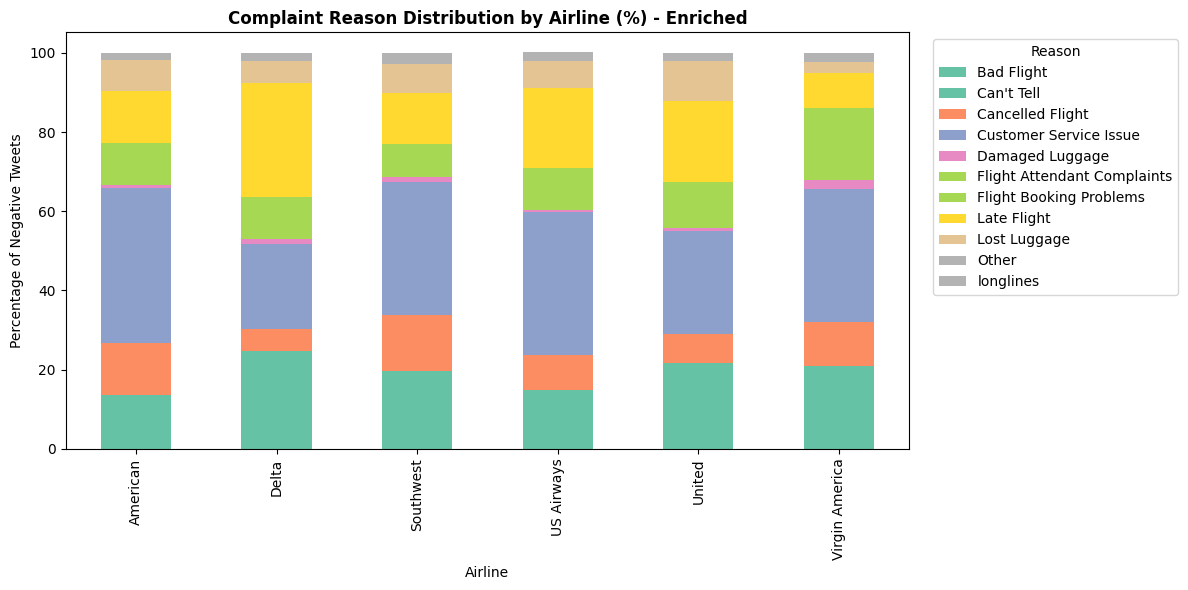

In [48]:
reason_airline_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Complaint Reason Distribution by Airline (%) - Enriched", fontweight="bold")
plt.ylabel("Percentage of Negative Tweets")
plt.xlabel("Airline")
plt.legend(title="Reason", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 2.6. Temporal Analysis (Hour of Day)

In [49]:
print("EXTRACTING HOUR OF DAY")

df_neg["tweet_created_dt"] = pd.to_datetime(df_neg["tweet_created"], errors="coerce")
df_neg["hour"] = df_neg["tweet_created_dt"].dt.hour

print("Missing timestamps:", df_neg["tweet_created_dt"].isnull().sum())

EXTRACTING HOUR OF DAY
Missing timestamps: 0


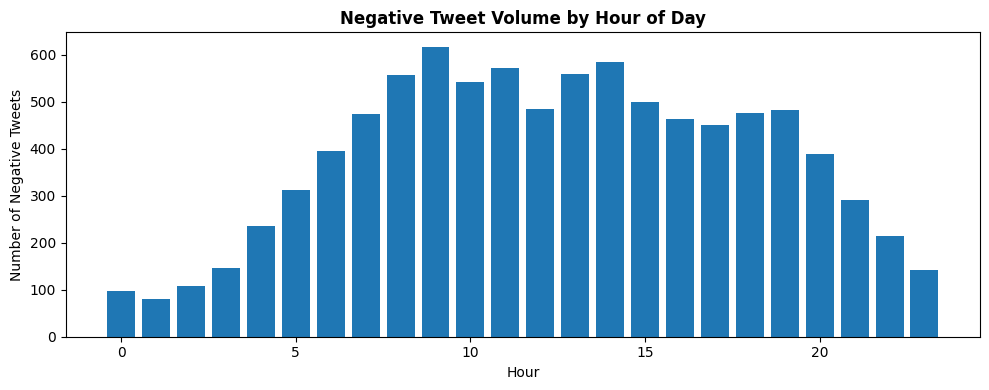

In [50]:
hour_counts = df_neg["hour"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(hour_counts.index, hour_counts.values)
plt.title("Negative Tweet Volume by Hour of Day", fontweight="bold")
plt.xlabel("Hour")
plt.ylabel("Number of Negative Tweets")
plt.tight_layout()
plt.show()

REASON MIX BY HOUR


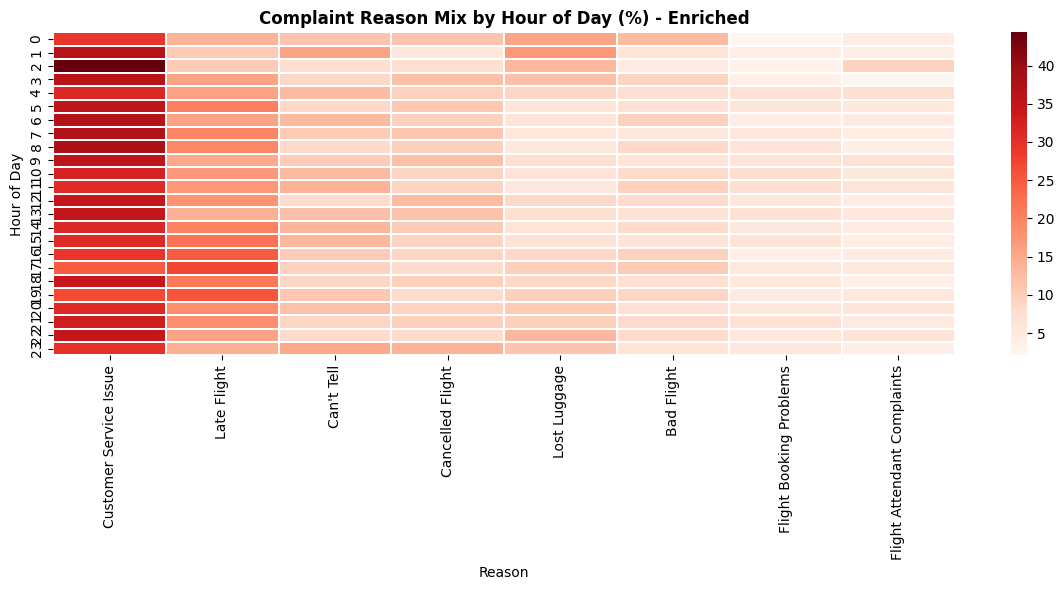

In [53]:
print("REASON MIX BY HOUR")

top_reason_list = df_neg["negativereason_enriched"].value_counts().head(8).index.tolist()

hour_reason = pd.crosstab(
    df_neg["hour"],
    df_neg["negativereason_enriched"]
)

hour_reason = hour_reason[top_reason_list]

hour_reason_pct = (
    hour_reason.div(hour_reason.sum(axis=1), axis=0) * 100
).fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(hour_reason_pct, cmap="Reds", linewidths=0.2)

plt.title("Complaint Reason Mix by Hour of Day (%) - Enriched", fontweight="bold")
plt.xlabel("Reason")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

### Step 3: Emotion Classification Using a Pretrained Transformer

Next, you should classify each tweet into one of seven emotions: anger, sadness, joy, fear, disgust, surprise, 
or  neutral  using  the  pretrained  transformer  model  j-hartmann/emotion-english-distilroberta-base.  After 
generating these emotion labels, you should analyze the emotional landscape of the dataset by examining how 
emotions vary across airlines, across time of day, and across reason categories. Include representative tweets 
for each emotion to validate that the model output aligns with human intuition, and comment on cases where the 
model’s interpretation feels ambiguous or incorrect.

In your report, you should describe which emotions dominate the dataset, what situations tend to evoke anger 
or  sadness,  and  which  airlines  see  higher  levels  of  frustration  or  appreciation.  You  should  also  discuss  what 
these  emotional  patterns  reveal  about  the  customer  experience  journey,  communication  expectations,  and 
common failure points in airline operations. 

#### 3.1. Load Pretrained Emotion Model

In [58]:
print("LOADING EMOTION CLASSIFICATION MODEL")

emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    max_length=512
)

LOADING EMOTION CLASSIFICATION MODEL


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

#### 3.2. Test the Model

In [59]:
print("TESTING EMOTION CLASSIFIER")

test_texts = [
    "I am so frustrated with this airline.",
    "Thank you Delta for the smooth flight!",
    "I'm worried I won't make my connection.",
    "Just checking on my reservation."
]

for text in test_texts:
    result = emotion_classifier(text)[0]
    top_emotion = max(result, key=lambda x: x['score'])

    print(f"\nText: \"{text}\"")
    print(f"Emotion: {top_emotion['label']} (confidence: {top_emotion['score']:.3f})")

    scores_str = ", ".join(
        [f"{r['label']}: {r['score']:.2f}"
         for r in sorted(result, key=lambda x: -x['score'])[:3]]
    )
    print(f"Top 3: {scores_str}")

TESTING EMOTION CLASSIFIER

Text: "I am so frustrated with this airline."
Emotion: anger (confidence: 0.964)
Top 3: anger: 0.96, sadness: 0.01, disgust: 0.01

Text: "Thank you Delta for the smooth flight!"
Emotion: joy (confidence: 0.868)
Top 3: joy: 0.87, neutral: 0.08, surprise: 0.04

Text: "I'm worried I won't make my connection."
Emotion: fear (confidence: 0.967)
Top 3: fear: 0.97, sadness: 0.01, neutral: 0.01

Text: "Just checking on my reservation."
Emotion: neutral (confidence: 0.962)
Top 3: neutral: 0.96, surprise: 0.02, sadness: 0.01


#### 3.3. Batch Classify All Tweets

In [61]:
# classify all tweets, not just negative
print("CLASSIFYING ALL TWEETS")

# recreate cleaned text column
if "text_clean" not in df_clean.columns:
    print("Rebuilding text_clean column...")
    df_clean["text_clean"] = df_clean["text"].apply(clean_text)

texts_to_classify = df_clean["text_clean"].astype(str).tolist()

batch_size = 32
all_results = []

for i in tqdm(range(0, len(texts_to_classify), batch_size)):
    batch = texts_to_classify[i:i+batch_size]
    batch = [text if text.strip() else "neutral text" for text in batch]

    results = emotion_classifier(batch)
    all_results.extend(results)

CLASSIFYING ALL TWEETS
Rebuilding text_clean column...


100%|██████████| 458/458 [09:24<00:00,  1.23s/it]


#### 3.4. Extract Top Emotion and Confidence

EXTRACTING TOP EMOTION
EMOTION DISTRIBUTION

Emotion Breakdown:
  sadness: 3,960 (27.0%)
  neutral: 3,942 (26.9%)
  surprise: 2,768 (18.9%)
  joy: 2,039 (13.9%)
  anger: 1,208 (8.3%)
  fear: 443 (3.0%)
  disgust: 280 (1.9%)


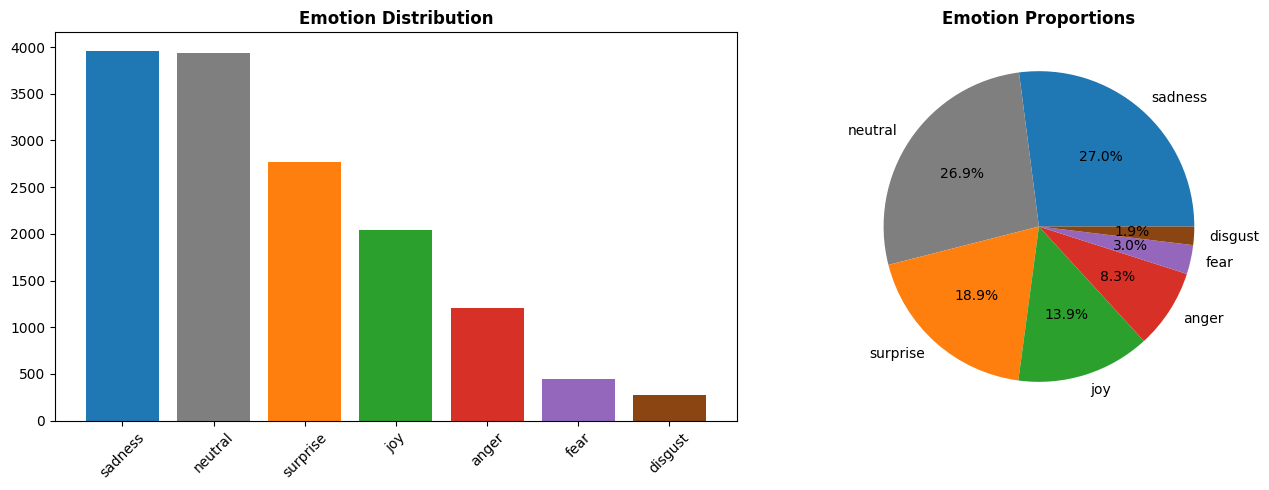

In [64]:
print("EXTRACTING TOP EMOTION")

emotions = []
confidences = []

for result in all_results:
    top = max(result, key=lambda x: x['score'])
    emotions.append(top['label'])
    confidences.append(top['score'])

df_clean["emotion"] = emotions
df_clean["emotion_confidence"] = confidences

# emotion distribution
print("EMOTION DISTRIBUTION")

emotion_counts = df_clean["emotion"].value_counts()
emotion_pct = (emotion_counts / len(df_clean) * 100).round(1)

print("\nEmotion Breakdown:")
for emotion in emotion_counts.index:
    print(f"  {emotion}: {emotion_counts[emotion]:,} ({emotion_pct[emotion]}%)")

# visualization
emotion_colors = {
    'anger': '#d73027',
    'disgust': '#8B4513',
    'fear': '#9467bd',
    'joy': '#2ca02c',
    'neutral': '#7f7f7f',
    'sadness': '#1f77b4',
    'surprise': '#ff7f0e'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [emotion_colors.get(e, '#333333') for e in emotion_counts.index]

axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title('Emotion Distribution', fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].pie(emotion_counts.values,
            labels=emotion_counts.index,
            autopct='%1.1f%%',
            colors=colors)

axes[1].set_title('Emotion Proportions', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.5. Representative Tweets by Emotion

In [65]:
print("SAMPLE TWEETS BY EMOTION")

for emotion in emotion_counts.index:
    print(f"\n--- {emotion.upper()} ---")

    samples = df_clean[df_clean["emotion"] == emotion][
        ["text_clean", "emotion_confidence"]
    ].head(3)

    for _, row in samples.iterrows():
        text = row["text_clean"][:150]
        print(f"[{row['emotion_confidence']:.2f}] {text}")

SAMPLE TWEETS BY EMOTION

--- SADNESS ---
[0.82] i didn't today must mean i need to take another trip!
[0.66] really missed a prime opportunity for men without hats parody there
[0.46] i flew from nyc to sfo last week and couldn't fully sit in my seat due to two large gentleman on either side of me help!

--- NEUTRAL ---
[0.48] what said
[0.63] plus you've added commercials to the experience tacky
[0.77] yes nearly every time i fly vx this ear worm won t go away

--- SURPRISE ---
[0.74] well i didn't but now i do! -d
[0.86] it was amazing and arrived an hour early you're too good to me
[0.53] did you know that suicide is the second leading cause of death among teens 10-24

--- JOY ---
[0.94] i lt 3 pretty graphics so much better than minimal iconography d
[0.95] this is such a great deal! already thinking about my 2nd trip to amp i haven't even gone on my 1st trip yet! p
[0.99] i'm flying your fabulous seductive skies again! u take all the stress away from travel

--- ANGER ---
[0.99] 

#### 3.6. Emotion by Airline

In [66]:
print("EMOTION BY AIRLINE (%)")

emotion_airline_pct = pd.crosstab(
    df_clean["airline"],
    df_clean["emotion"],
    normalize="index"
) * 100

emotion_airline_pct = emotion_airline_pct.round(1)
display(emotion_airline_pct)

EMOTION BY AIRLINE (%)


emotion,anger,disgust,fear,joy,neutral,sadness,surprise
airline,,,,,,,
American,10.0,2.1,2.7,10.5,25.3,32.6,16.9
Delta,5.6,1.0,3.6,20.4,31.8,18.0,19.4
Southwest,6.6,1.2,2.1,19.6,26.7,24.7,19.1
US Airways,10.3,2.4,3.4,9.5,23.4,32.0,18.9
United,8.7,2.5,3.2,11.1,28.2,26.6,19.6
Virgin America,3.4,0.8,2.8,23.4,26.2,22.2,21.2


#### 3.7. Emotion by Hour of Day

EMOTION MIX BY HOUR


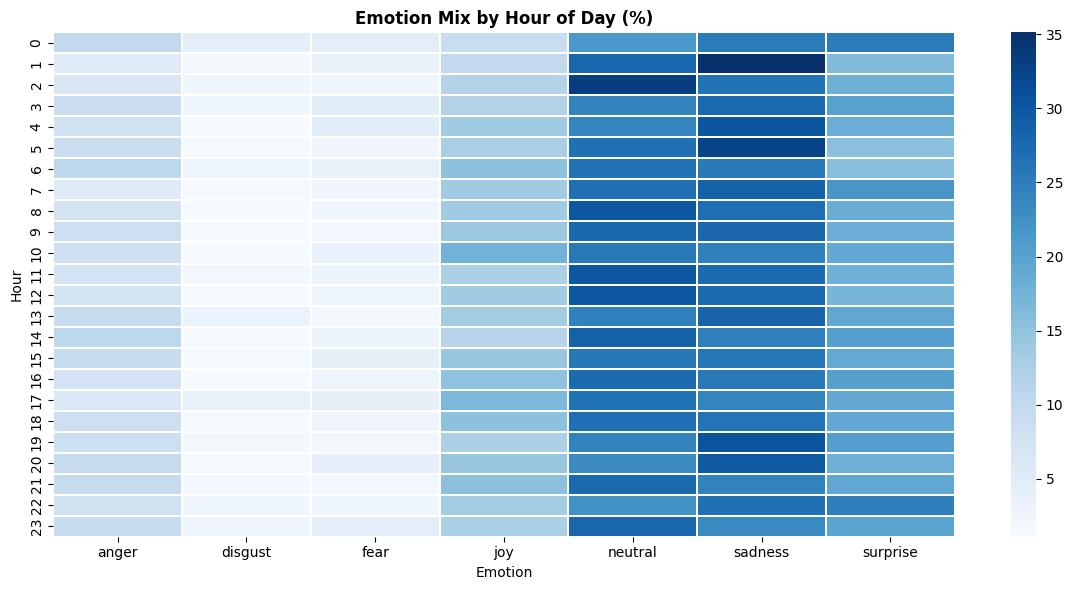

In [67]:
print("EMOTION MIX BY HOUR")

df_clean["tweet_created_dt"] = pd.to_datetime(df_clean["tweet_created"], errors="coerce")
df_clean["hour"] = df_clean["tweet_created_dt"].dt.hour

hour_emotion = pd.crosstab(
    df_clean["hour"],
    df_clean["emotion"]
)

hour_emotion_pct = (
    hour_emotion.div(hour_emotion.sum(axis=1), axis=0) * 100
).fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(hour_emotion_pct, cmap="Blues", linewidths=0.2)

plt.title("Emotion Mix by Hour of Day (%)", fontweight="bold")
plt.xlabel("Emotion")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

#### 3.8. Emotion by Reason for Complaint

In [69]:
print("EMOTION BY COMPLAINT REASON (%)")

# ensure df_neg has emotion column from df_clean
if "emotion" not in df_neg.columns:
    df_neg = df_neg.merge(
        df_clean[["tweet_id", "emotion"]],
        on="tweet_id",
        how="left"
    )

emotion_reason_pct = pd.crosstab(
    df_neg["negativereason_enriched"],
    df_neg["emotion"],
    normalize="index"
) * 100

emotion_reason_pct = emotion_reason_pct.round(1)

display(emotion_reason_pct)

EMOTION BY COMPLAINT REASON (%)


emotion,anger,disgust,fear,joy,neutral,sadness,surprise
negativereason_enriched,,,,,,,
Bad Flight,11.4,9.4,7.3,4.4,16.2,29.6,21.7
Can't Tell,15.6,3.9,4.6,6.0,26.0,24.4,19.5
Cancelled Flight,8.5,0.9,2.1,1.6,6.1,68.9,12.0
Customer Service Issue,13.8,3.1,4.1,4.0,23.0,33.3,18.6
Damaged Luggage,17.6,0.0,4.1,5.4,16.2,37.8,18.9
Flight Attendant Complaints,29.4,4.0,5.7,3.4,23.7,18.9,14.9
Flight Booking Problems,8.4,0.9,2.2,2.2,19.6,44.7,22.0
Late Flight,7.6,1.5,2.8,3.5,22.8,38.3,23.5
Lost Luggage,10.7,1.2,2.2,2.9,23.2,35.6,24.2


### Step 4: Language & Expression Analysis

Analyze how passengers express emotions through linguistic and stylistic patterns in their tweets. This includes 
comparing tweet length, the frequency of direct @mentions, emoji usage, use of emphasis or capitalization, and 
the most common unigrams and bigrams within each emotion category. Your goal in this section is to understand 
the communication style associated with different emotional states. For example, you may observe that angry 
tweets tend to be longer and more direct, while joyful tweets may be brief and expressive. In your report, you 
should  summarize  the  most  important  linguistic  contrasts  you  observe  and  explain  how  these  communication 
patterns  can  help  product  managers  and  customer  service  teams  interpret  emotional  cues  in  user-generated 
text. 

#### 4.1. Tweet Length and Word Count by Emotion

TWEET LENGTH BY EMOTION
sadness: 19.2 words
anger: 18.3 words
fear: 17.2 words
surprise: 17.2 words
disgust: 15.8 words
neutral: 14.4 words
joy: 13.5 words


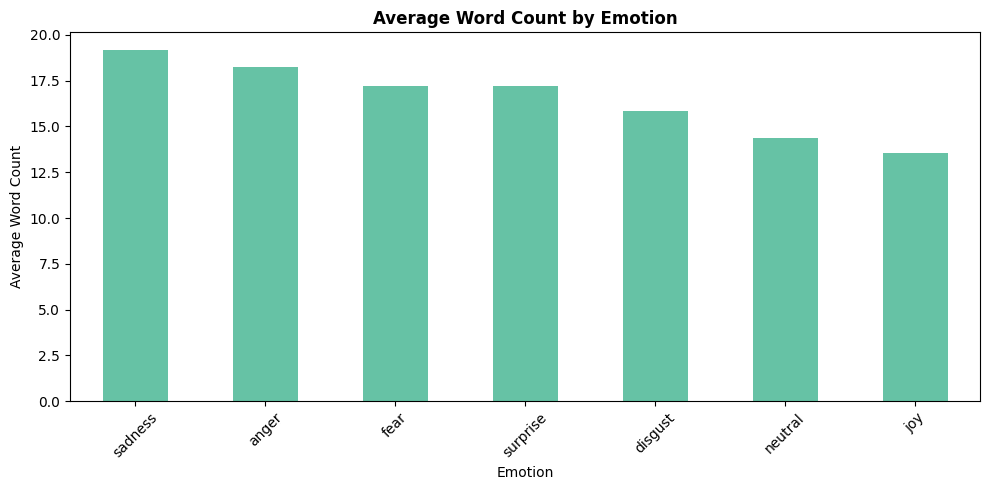

In [70]:
print("TWEET LENGTH BY EMOTION")

# ensure text features exist
if "text_length" not in df_clean.columns:
    df_clean["text_length"] = df_clean["text_clean"].apply(len)
    df_clean["word_count"] = df_clean["text_clean"].apply(lambda x: len(str(x).split()))

length_by_emotion = df_clean.groupby("emotion")["word_count"].mean().sort_values(ascending=False)

for emotion, avg_words in length_by_emotion.items():
    print(f"{emotion}: {avg_words:.1f} words")

# visualization
plt.figure(figsize=(10,5))
length_by_emotion.plot(kind="bar", colormap="Set2")
plt.title("Average Word Count by Emotion", fontweight="bold")
plt.ylabel("Average Word Count")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.2. @Mention Frequency by Emotion

MENTION FREQUENCY BY EMOTION
neutral: 1.15 mentions per tweet
joy: 1.15 mentions per tweet
anger: 1.13 mentions per tweet
surprise: 1.12 mentions per tweet
fear: 1.11 mentions per tweet
disgust: 1.10 mentions per tweet
sadness: 1.10 mentions per tweet


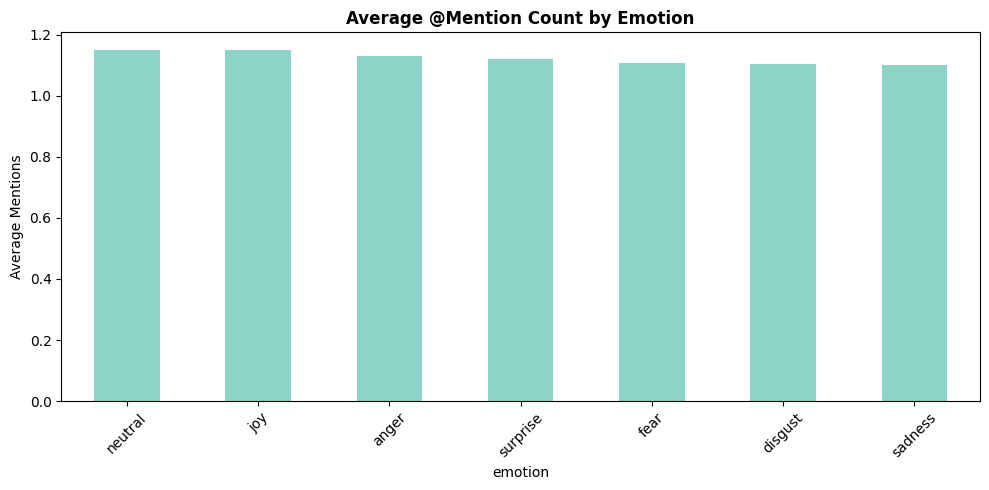

In [71]:
print("MENTION FREQUENCY BY EMOTION")

# Count @mentions in original tweet
df_clean["mention_count"] = df_clean["text"].str.count(r"@\w+")

mention_by_emotion = df_clean.groupby("emotion")["mention_count"].mean().sort_values(ascending=False)

for emotion, avg_mentions in mention_by_emotion.items():
    print(f"{emotion}: {avg_mentions:.2f} mentions per tweet")

plt.figure(figsize=(10,5))
mention_by_emotion.plot(kind="bar", colormap="Set3")
plt.title("Average @Mention Count by Emotion", fontweight="bold")
plt.ylabel("Average Mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.3. Emoji Usage by Emotion

EMOJI USAGE BY EMOTION
joy: 0.09 emojis per tweet
fear: 0.09 emojis per tweet
surprise: 0.08 emojis per tweet
neutral: 0.05 emojis per tweet
sadness: 0.04 emojis per tweet
anger: 0.03 emojis per tweet
disgust: 0.03 emojis per tweet


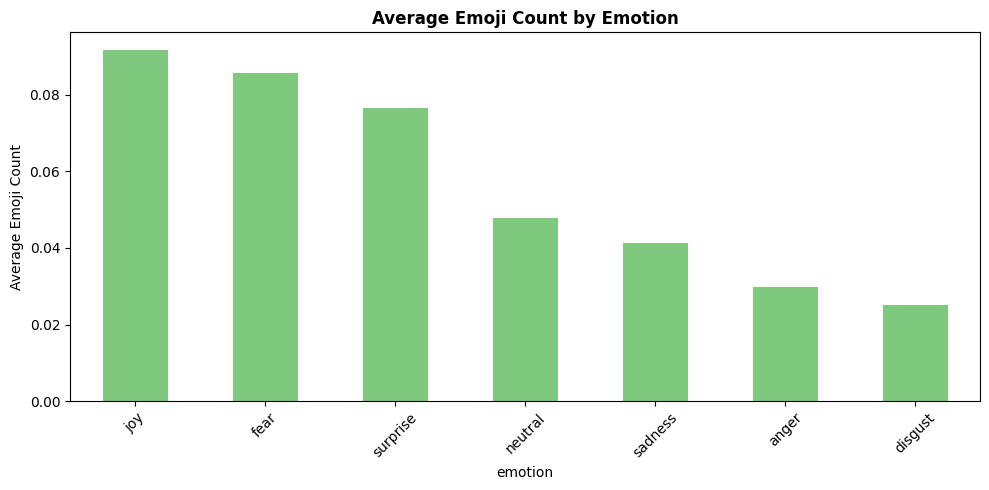

In [ ]:
print("EMOJI USAGE BY EMOTION")

# via unicode ranges for common emojis
emoji_pattern = r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]'

df_clean["emoji_count"] = df_clean["text"].str.count(emoji_pattern)

emoji_by_emotion = df_clean.groupby("emotion")["emoji_count"].mean().sort_values(ascending=False)

for emotion, avg_emoji in emoji_by_emotion.items():
    print(f"{emotion}: {avg_emoji:.2f} emojis per tweet")

plt.figure(figsize=(10,5))
emoji_by_emotion.plot(kind="bar", colormap="Accent")
plt.title("Average Emoji Count by Emotion", fontweight="bold")
plt.ylabel("Average Emoji Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.4. Capitalization/Emphasis

CAPITALIZATION / EMPHASIS ANALYSIS
surprise: 0.42 ALL CAPS words per tweet
sadness: 0.41 ALL CAPS words per tweet
fear: 0.35 ALL CAPS words per tweet
anger: 0.35 ALL CAPS words per tweet
disgust: 0.34 ALL CAPS words per tweet
joy: 0.32 ALL CAPS words per tweet
neutral: 0.31 ALL CAPS words per tweet


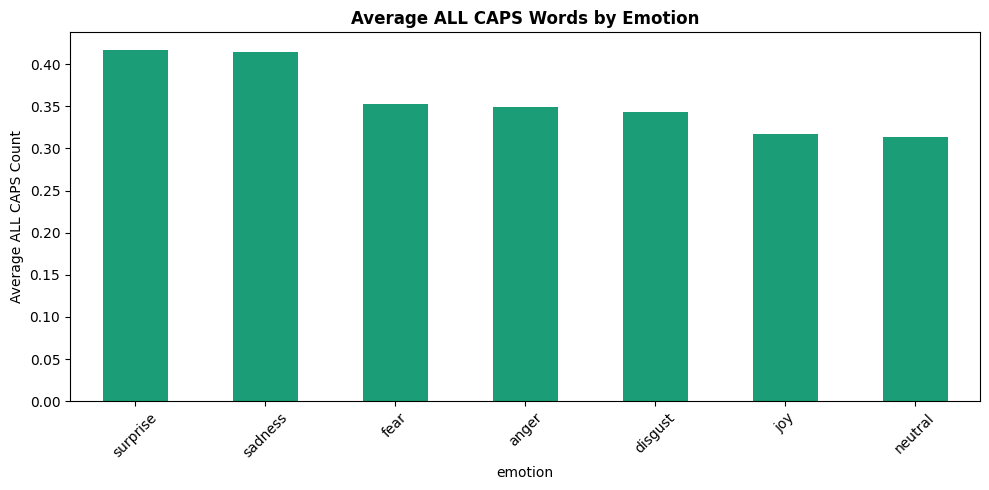

In [73]:
print("CAPITALIZATION / EMPHASIS ANALYSIS")

def count_all_caps(text):
    words = str(text).split()
    return sum(1 for w in words if w.isupper() and len(w) > 2)

df_clean["all_caps_count"] = df_clean["text"].apply(count_all_caps)

caps_by_emotion = df_clean.groupby("emotion")["all_caps_count"].mean().sort_values(ascending=False)

for emotion, avg_caps in caps_by_emotion.items():
    print(f"{emotion}: {avg_caps:.2f} ALL CAPS words per tweet")

plt.figure(figsize=(10,5))
caps_by_emotion.plot(kind="bar", colormap="Dark2")
plt.title("Average ALL CAPS Words by Emotion", fontweight="bold")
plt.ylabel("Average ALL CAPS Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4.5. Top Unigrams and Bigrams by Emotion (n-grams)

In [78]:
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

def get_top_ngrams(texts, n=1, top_k=10):
    tokens_all = []
    
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
        
        if n == 1:
            tokens_all.extend(tokens)
        else:
            tokens_all.extend([" ".join(g) for g in ngrams(tokens, n)])
    
    return Counter(tokens_all).most_common(top_k)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lucashuynh/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [79]:
# top unigrams by emotion
print("TOP UNIGRAMS BY EMOTION")

for emotion in df_clean["emotion"].unique():
    emotion_texts = df_clean[df_clean["emotion"] == emotion]["text_clean"].tolist()
    
    if len(emotion_texts) > 0:
        top_words = get_top_ngrams(emotion_texts, n=1, top_k=8)
        words_str = ", ".join([w for w, c in top_words])
        print(f"\n{emotion.upper()}: {words_str}")

TOP UNIGRAMS BY EMOTION

NEUTRAL: flight, get, please, thanks, time, would, help, hold

SADNESS: flight, cancelled, get, help, flightled, delayed, amp, hours

ANGER: flight, service, rude, customer, get, hold, time, cancelled

DISGUST: worst, service, customer, ever, flight, airline, guys, suck

SURPRISE: flight, get, plane, time, thanks, hours, one, still

JOY: thanks, thank, flight, great, service, love, would, much

FEAR: flight, service, terrible, horrible, customer, experience, get, time


In [80]:
# top bigrams by emotion
print("TOP BIGRAMS BY EMOTION")

for emotion in df_clean["emotion"].unique():
    emotion_texts = df_clean[df_clean["emotion"] == emotion]["text_clean"].tolist()
    
    if len(emotion_texts) > 0:
        top_bigrams = get_top_ngrams(emotion_texts, n=2, top_k=5)
        bigrams_str = ", ".join([bg for bg, c in top_bigrams])
        print(f"\n{emotion.upper()}: {bigrams_str}")

TOP BIGRAMS BY EMOTION

NEUTRAL: customer service, fleet fleek, late flight, booking problems, call back

SADNESS: cancelled flightled, cancelled flighted, flight cancelled, customer service, late flight

ANGER: customer service, cancelled flightled, late flight, gate agent, worst airline

DISGUST: customer service, worst customer, worst airline, airline ever, guys suck

SURPRISE: customer service, late flight, cancelled flightled, late flightr, flight delayed

JOY: customer service, thank much, thanks much, great flight, looking forward

FEAR: customer service, fleet fleek, terrible customer, cancelled flightled, terrible service
